<a href="https://colab.research.google.com/github/flynnight/Tubes-Siscer/blob/main/ML_Medical_Insurance_Regresi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Prediksi Biaya Asuransi Kesehatan Menggunakan Decision Tree Regressor, Naïve Bayes, dan K-Nearest Neighbors Regressor**

---
> **Level 2: AI-Assisted Idea Generation & Structuring**
---

## 3.1 Topik & Identitas

**Judul Studi Kasus:** Perbandingan KNN dan Decision Tree Untuk Estimasi Biaya Asuransi Kesehatan Menggunakan Fitur Smoker dan BMI

| Nama | NIM |
|------|-----|
| Fathahul Rizqa Arrahman | 103032430013 |
| Febriani Zahra | 103032400034 |
| Muhammad Maulana Darmawansyah | 103032400081 |

**Sumber Dataset:** [Kaggle - Medical Cost Personal Datasets](https://www.kaggle.com/code/fredericksalazar/linear-regresion-medical-charges-insurance/input)


---
## 📦 Instalasi & Import Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --- Algoritma Regresi ---
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
from sklearn.neighbors import KNeighborsRegressor
# Naive Bayes tidak punya varian regresi resmi di sklearn;
# kita implementasikan Gaussian Naive Bayes Regressor secara manual
# berdasarkan estimasi E[y | X] dari distribusi posterior.

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import KFold, GridSearchCV, cross_val_predict, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, RegressorMixin

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('✅ Semua library berhasil diimport!')

✅ Semua library berhasil diimport!


---
## Load Dataset

> **Cara upload dataset:**  
> 1. Download file `insurance.csv` dari [Kaggle](https://www.kaggle.com/code/fredericksalazar/linear-regresion-medical-charges-insurance/input)  
> 2. Upload ke Google Colab menggunakan cell di bawah

In [ ]:
df = pd.read_csv('insurance.csv')
print(f'\n✅ Dataset berhasil dimuat! Shape: {df.shape}')
df_kolom = df[['bmi', 'smoker', 'charges']]
df_kolom.head()


✅ Dataset berhasil dimuat! Shape: (1338, 7)


,bmi,smoker,charges
0,27.900,yes,16884.92400
1,33.770,no,1725.55230
2,33.000,no,4449.46200
3,22.705,no,21984.47061
4,28.880,no,3866.85520


---
## 3.2 Pendahuluan & Pemaparan Data

### 3.2.1 Latar Belakang & Rumusan Masalah

Biaya asuransi kesehatan bervariasi secara signifikan antar individu, dipengaruhi oleh faktor-faktor seperti usia, BMI, kebiasaan merokok, jumlah tanggungan, jenis kelamin, dan wilayah tinggal. Prediksi biaya yang akurat sangat penting bagi perusahaan asuransi dalam menetapkan premi yang tepat dan adil.

**Rumusan Masalah:** Seberapa akurat algoritma *Decision Tree Regressor*, *Naïve Bayes Regressor*, dan *K-Nearest Neighbors Regressor* dapat memprediksi nilai numerik biaya asuransi kesehatan (`charges`) berdasarkan karakteristik individu?

**Target Variabel:** `charges` (kontinu, USD) — ini adalah **masalah REGRESI**.

### 3.2.2 Deskripsi Dataset

| Fitur | Tipe | Keterangan |
|-------|------|------------|
| `age` | Numerik | Usia pemegang polis |
| `sex` | Kategorik | Jenis kelamin (male/female) |
| `bmi` | Numerik | Body Mass Index |
| `children` | Numerik | Jumlah anak tanggungan |
| `smoker` | Kategorik | Status merokok (yes/no) |
| `region` | Kategorik | Wilayah tinggal di AS |
| `charges` | **Target** | Biaya asuransi (USD) |

In [ ]:
# ============================================================
# 3.2 — Eksplorasi Data Awal
# ============================================================
print('INFORMASI DATASET')
print('='*50)
print(f'Baris  : {df.shape[0]}')
print(f'Kolom  : {df.shape[1]}')
print()
df.info()

INFORMASI DATASET
Baris  : 1338
Kolom  : 7

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
# Statistik Deskriptif
df.describe().round(2)

,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


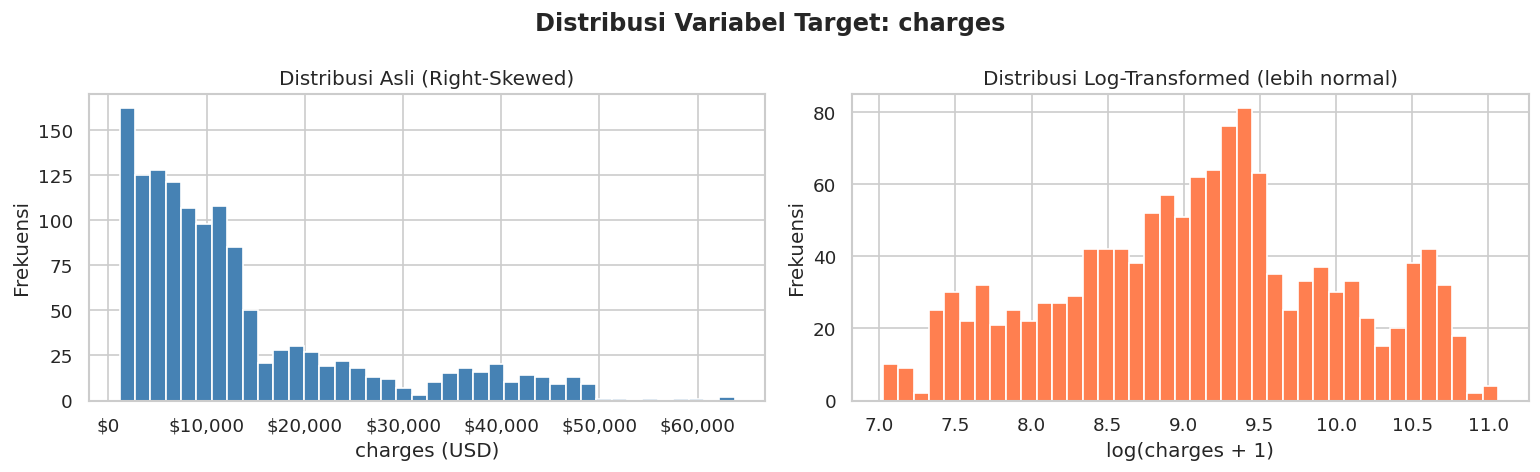

Skewness charges         : 1.5159
Skewness log(charges+1)  : -0.0898


In [ ]:
# ============================================================
# Distribusi Target Variable: charges
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Distribusi Variabel Target: charges', fontweight='bold')

axes[0].hist(df['charges'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Asli (Right-Skewed)')
axes[0].set_xlabel('charges (USD)')
axes[0].set_ylabel('Frekuensi')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

axes[1].hist(np.log1p(df['charges']), bins=40, color='coral', edgecolor='white')
axes[1].set_title('Distribusi Log-Transformed (lebih normal)')
axes[1].set_xlabel('log(charges + 1)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

print(f'Skewness charges         : {df["charges"].skew():.4f}')
print(f'Skewness log(charges+1)  : {np.log1p(df["charges"]).skew():.4f}')

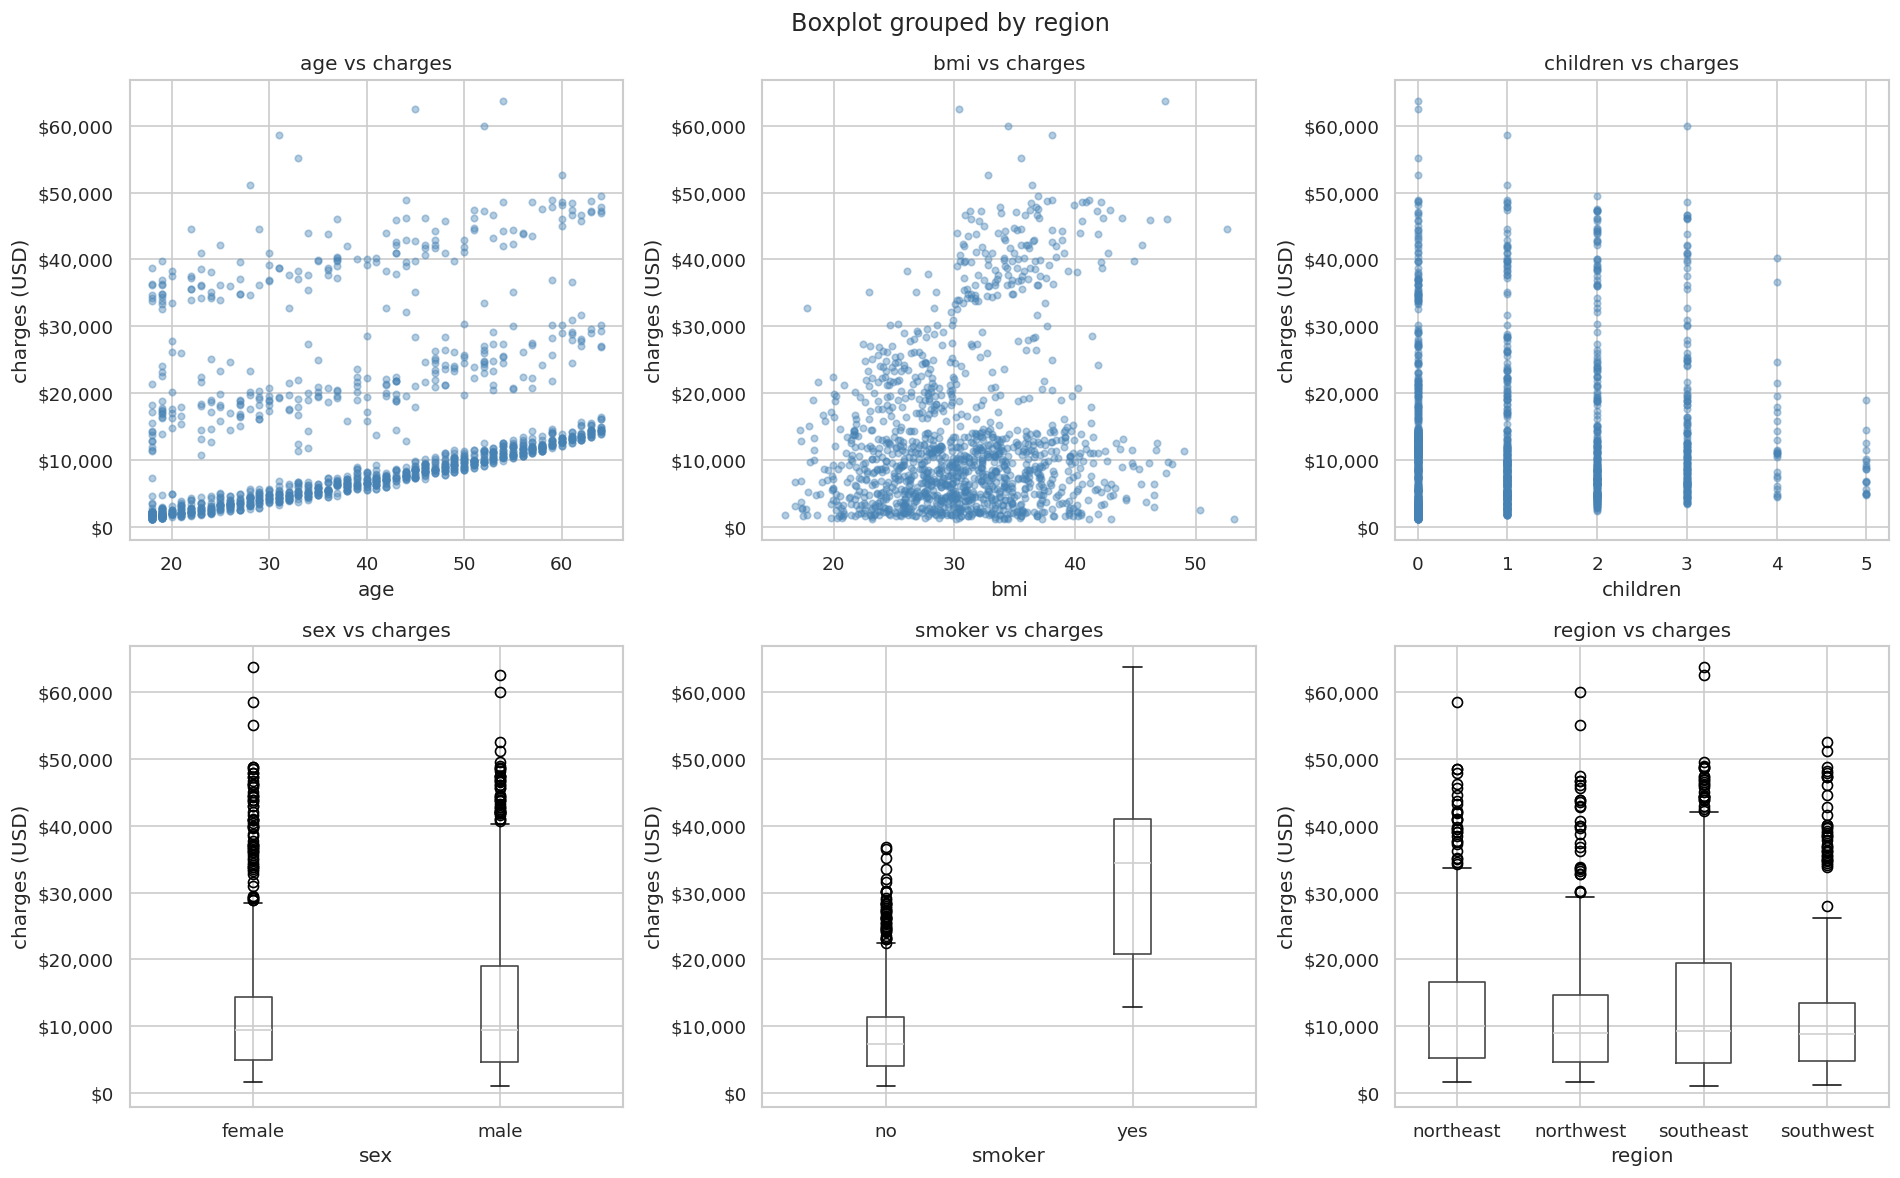

In [ ]:
# ============================================================
# EDA: Hubungan Fitur terhadap Target
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Hubungan Setiap Fitur terhadap Biaya Asuransi (charges)', fontsize=14, fontweight='bold')

# Scatter plots: numerik vs charges
for i, col in enumerate(['age', 'bmi', 'children']):
    axes[0, i].scatter(df[col], df['charges'], alpha=0.4, color='steelblue', s=15)
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('charges (USD)')
    axes[0, i].set_title(f'{col} vs charges')
    axes[0, i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Box plots: kategorik vs charges
for i, col in enumerate(['sex', 'smoker', 'region']):
    df.boxplot(column='charges', by=col, ax=axes[1, i])
    axes[1, i].set_title(f'{col} vs charges')
    axes[1, i].set_xlabel(col)
    axes[1, i].set_ylabel('charges (USD)')
    axes[1, i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

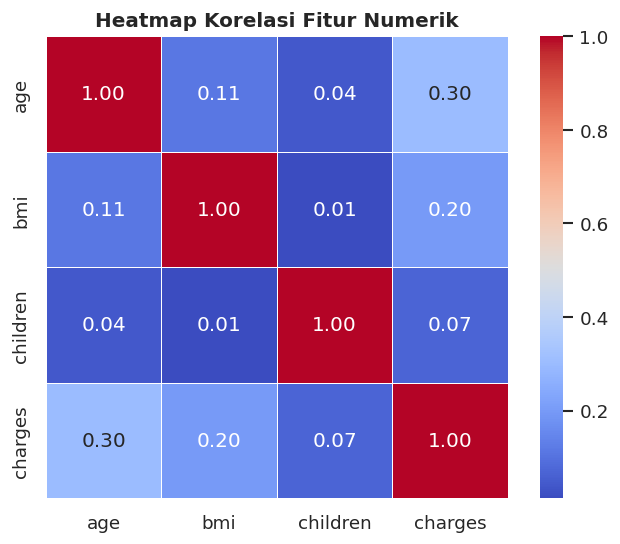

In [ ]:
# Heatmap Korelasi
plt.figure(figsize=(7, 5))
corr = df[['age', 'bmi', 'children', 'charges']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik', fontweight='bold')
plt.show()

---
## 3.3 Pra-Pemrosesan Data

In [ ]:
# ============================================================
# 3.3.1 — Cek Missing Values & Duplikat
# ============================================================
print('Missing Values per Kolom:')
print(df.isnull().sum())
print(f'\nJumlah baris duplikat: {df.duplicated().sum()}')

df = df.drop_duplicates().reset_index(drop=True)
print(f'Shape setelah menghapus duplikat: {df.shape}')

Missing Values per Kolom:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Jumlah baris duplikat: 1
Shape setelah menghapus duplikat: (1337, 7)


In [ ]:
# ============================================================
# 3.3.2 — Encoding Variabel Kategorik
# ============================================================
df_model = df.copy()

# Label Encoding
le = LabelEncoder()
cat_cols = ['sex', 'smoker', 'region']
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

print('Encoding selesai. Mapping:')
for col in cat_cols:
    print(f'  {col}: {dict(enumerate(LabelEncoder().fit(df[col]).classes_))}')

df_model.head()

Encoding selesai. Mapping:
  sex: {0: 'female', 1: 'male'}
  smoker: {0: 'no', 1: 'yes'}
  region: {0: 'northeast', 1: 'northwest', 2: 'southeast', 3: 'southwest'}


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [ ]:
# ============================================================
# 3.3.3 — Feature Engineering
# ============================================================

# BMI Category (Underweight / Normal / Overweight / Obese)
df_model['bmi_category'] = pd.cut(df['bmi'],
    bins=[0, 18.5, 25.0, 30.0, 100.0],
    labels=[0, 1, 2, 3]).astype(int)

# Age Group
df_model['age_group'] = pd.cut(df['age'],
    bins=[17, 30, 45, 65],
    labels=[0, 1, 2]).astype(int)

# Interaksi: smoker × bmi (fitur interaksi kuat)
df_model['smoker_bmi'] = df_model['smoker'] * df_model['bmi']

# Interaksi: smoker × age
df_model['smoker_age'] = df_model['smoker'] * df_model['age']

print('Fitur setelah Feature Engineering:')
print(df_model.columns.tolist())

Fitur setelah Feature Engineering:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'bmi_category', 'age_group', 'smoker_bmi', 'smoker_age']


In [ ]:
# Pisahkan X dan y
# Target: charges (nilai asli, BUKAN log) — model dilatih pada skala asli
X = df_model.drop(columns=['charges'])
y = df_model['charges']

# Juga siapkan y_log untuk percobaan log-transform
y_log = np.log1p(y)

print(f'Shape X : {X.shape}')
print(f'Shape y : {y.shape}')
print(f'\nStatistik target (charges):')
print(y.describe().round(2))

Shape X : (1337, 10)
Shape y : (1337,)

Statistik target (charges):
count     1337.00
mean     13279.12
std      12110.36
min       1121.87
25%       4746.34
50%       9386.16
75%      16657.72
max      63770.43
Name: charges, dtype: float64


---
## 3.4 Penanganan Skewness Target Variable

Pada masalah regresi, **tidak ada imbalanced data** seperti pada klasifikasi. Namun, distribusi target yang sangat skewed (*right-skewed* seperti `charges`) dapat memperburuk performa model. Strategi yang digunakan:

In [ ]:
# ============================================================
# 3.4 — Perbandingan: Target Asli vs Log-Transformed
# ============================================================
from scipy import stats

skew_orig = y.skew()
skew_log  = y_log.skew()

print(f'Skewness charges asli      : {skew_orig:.4f}  (skewed, >1 dianggap tinggi)')
print(f'Skewness log(charges+1)    : {skew_log:.4f}  (lebih mendekati normal)')

# Kita akan melatih dua versi dan membandingkan — target asli dan log
print('\nStrategi:')
print('  - Melatih model dengan target ASLI dan target LOG-TRANSFORMED')
print('  - Untuk target log, prediksi di-invers (expm1) sebelum evaluasi')
print('  - Metrik evaluasi dihitung pada skala ASLI (USD) untuk perbandingan yang adil')

Skewness charges asli      : 1.5154  (skewed, >1 dianggap tinggi)
Skewness log(charges+1)    : -0.0896  (lebih mendekati normal)

Strategi:
  - Melatih model dengan target ASLI dan target LOG-TRANSFORMED
  - Untuk target log, prediksi di-invers (expm1) sebelum evaluasi
  - Metrik evaluasi dihitung pada skala ASLI (USD) untuk perbandingan yang adil


---
## 3.5 Metode & Eksperimen

### Konsep Algoritma

**1. Decision Tree Regressor**  
Decision Tree untuk regresi mempartisi ruang fitur secara rekursif menggunakan kriteria seperti *Mean Squared Error (MSE)* atau *Mean Absolute Error (MAE)*. Setiap *leaf node* menghasilkan nilai prediksi berupa rata-rata nilai target pada subset data tersebut. Kelebihan utamanya adalah kemampuan menangkap hubungan non-linear dan interaksi antar fitur secara otomatis.

**2. Naïve Bayes Regressor (Gaussian NB — Pendekatan Probabilistik)**  
Naive Bayes tidak memiliki implementasi regresi bawaan di scikit-learn. Pendekatan yang digunakan adalah **Gaussian Naive Bayes Regressor** yang diimplementasikan secara manual: model mengestimasi distribusi P(y | X) dengan mengasumsikan P(X | y) ~ Gaussian untuk setiap fitur, lalu menggunakan *binning* target untuk membangun distribusi prior, dan memperkirakan nilai target sebagai E[y | X] berdasarkan posterior yang dihitung.

**3. K-Nearest Neighbors Regressor**  
KNN Regressor memprediksi nilai target dengan merata-ratakan nilai target dari *k* tetangga terdekat dalam ruang fitur. Jarak diukur menggunakan metrik Euclidean atau Manhattan. Karena berbasis jarak, fitur perlu di-*scale* terlebih dahulu agar satu fitur tidak mendominasi.

In [ ]:
# ============================================================
# 3.5.0 — Custom Naive Bayes Regressor
# ============================================================
class GaussianNBRegressor(BaseEstimator, RegressorMixin):
    """
    Naive Bayes Regressor berbasis pendekatan probabilistik:
    1. Diskritisasi y ke dalam n_bins bin (prior)
    2. Setiap fitur diasumsikan Gaussian per bin (likelihood)
    3. Prediksi = E[y | X] = sum(bin_mean * P(bin | X))

    Parameter:
        n_bins     : jumlah bin untuk diskritisasi target
        var_smooth : smoothing varians agar tidak nol
    """
    def __init__(self, n_bins=20, var_smoothing=1e-9):
        self.n_bins       = n_bins
        self.var_smoothing = var_smoothing

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)

        # Diskritisasi target ke n_bins bin menggunakan quantile
        self.bin_edges_ = np.percentile(y, np.linspace(0, 100, self.n_bins + 1))
        # Hindari edge duplikat
        self.bin_edges_ = np.unique(self.bin_edges_)
        y_binned = np.digitize(y, self.bin_edges_[1:-1])

        self.classes_   = np.unique(y_binned)
        self.n_classes_ = len(self.classes_)
        self.n_features_ = X.shape[1]

        # Hitung prior, mean, dan varians per kelas per fitur
        self.priors_ = np.zeros(self.n_classes_)
        self.theta_  = np.zeros((self.n_classes_, self.n_features_))  # mean
        self.sigma_  = np.zeros((self.n_classes_, self.n_features_))  # varians
        self.bin_means_ = np.zeros(self.n_classes_)                   # rata-rata y per bin

        for i, cls in enumerate(self.classes_):
            mask = (y_binned == cls)
            X_cls = X[mask]
            self.priors_[i]    = mask.sum() / len(y)
            self.theta_[i]     = X_cls.mean(axis=0)
            self.sigma_[i]     = X_cls.var(axis=0) + self.var_smoothing
            self.bin_means_[i] = y[mask].mean()

        return self

    def _log_likelihood(self, X):
        """Log P(X | class) untuk setiap sampel dan kelas."""
        n_samples = X.shape[0]
        log_lik   = np.zeros((n_samples, self.n_classes_))
        for i in range(self.n_classes_):
            diff       = X - self.theta_[i]
            log_lik[:, i] = -0.5 * np.sum(
                np.log(2 * np.pi * self.sigma_[i]) + (diff**2) / self.sigma_[i],
                axis=1
            )
        return log_lik

    def predict(self, X):
        X        = np.array(X)
        log_lik  = self._log_likelihood(X)
        log_post = log_lik + np.log(self.priors_ + 1e-300)

        # Stabilisasi: kurangi max (log-sum-exp trick)
        log_post -= log_post.max(axis=1, keepdims=True)
        post     = np.exp(log_post)
        post    /= post.sum(axis=1, keepdims=True)

        # Prediksi = rata-rata tertimbang nilai target per bin
        return post @ self.bin_means_

print('✅ GaussianNBRegressor berhasil didefinisikan.')
print('   Konsep: E[y|X] = Σ P(bin|X) × mean_y_per_bin')

✅ GaussianNBRegressor berhasil didefinisikan.
   Konsep: E[y|X] = Σ P(bin|X) × mean_y_per_bin


In [ ]:
# ============================================================
# 3.5.1 — Setup Cross-Validation
# ============================================================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Metrik Regresi
def regression_metrics(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    if label:
        print(f'  MAE  : ${mae:,.2f}')
        print(f'  RMSE : ${rmse:,.2f}')
        print(f'  R²   : {r2:.4f}')
        print(f'  MAPE : {mape:.2f}%')
    return {'MAE': mae, 'RMSE': rmse, 'R²': r2, 'MAPE': mape}

print('Cross-Validation: KFold (k=5)')
print('Metrik: MAE, RMSE, R², MAPE')

Cross-Validation: KFold (k=5)
Metrik: MAE, RMSE, R², MAPE


In [ ]:
# ============================================================
# MODEL 1: Decision Tree Regressor
# ============================================================
print('='*55)
print('  MODEL 1: Decision Tree Regressor')
print('='*55)

dt_pipeline = Pipeline([
    ('reg', DecisionTreeRegressor(random_state=42))
])

dt_params = {
    'reg__criterion'       : ['squared_error', 'absolute_error'],
    'reg__max_depth'       : [3, 5, 7, 10, None],
    'reg__min_samples_split': [2, 5, 10],
    'reg__min_samples_leaf' : [1, 2, 4]
}

dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_params,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
dt_grid.fit(X, y)

print(f'Best Params  : {dt_grid.best_params_}')
print(f'Best CV RMSE : ${-dt_grid.best_score_:,.2f}')

# Prediksi lintas fold
dt_best   = dt_grid.best_estimator_
dt_pred   = cross_val_predict(dt_best, X, y, cv=kf)

print('\nMetrik (cross-val predict):')
dt_metrics = regression_metrics(y, dt_pred, label=True)

  MODEL 1: Decision Tree Regressor
Best Params  : {'reg__criterion': 'absolute_error', 'reg__max_depth': 7, 'reg__min_samples_leaf': 4, 'reg__min_samples_split': 2}
Best CV RMSE : $4,674.38

Metrik (cross-val predict):
  MAE  : $1,889.08
  RMSE : $4,692.94
  R²   : 0.8497
  MAPE : 13.19%


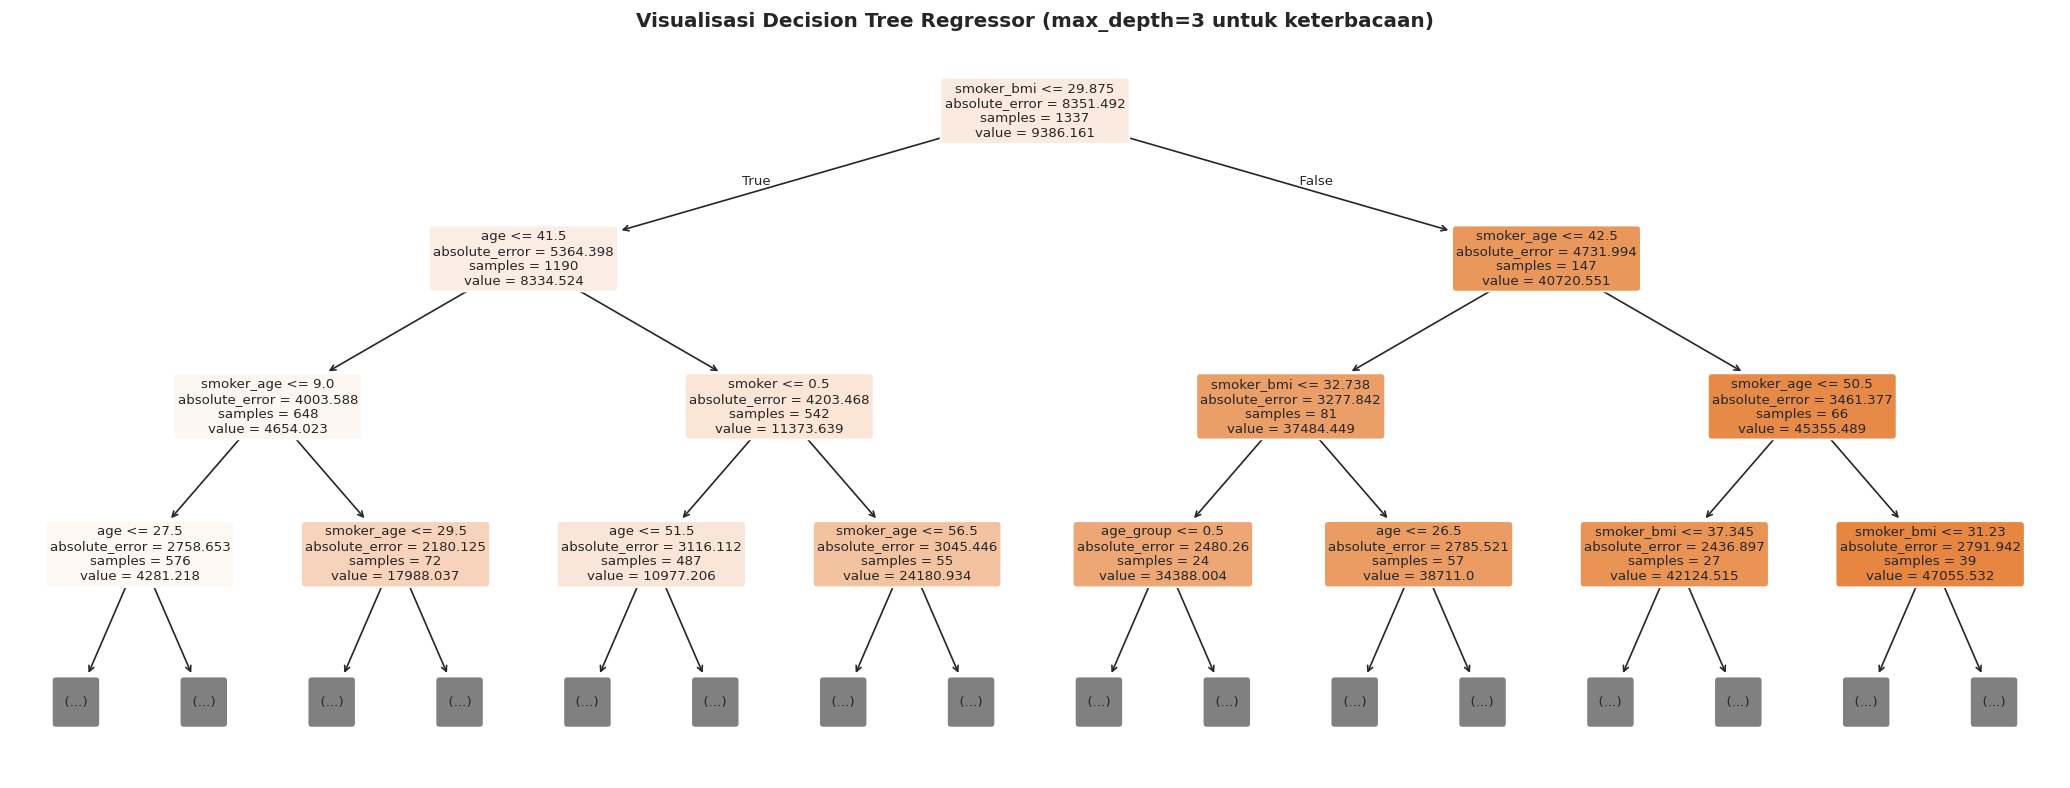

In [ ]:
# Visualisasi Decision Tree
dt_best.fit(X, y)
dt_reg = dt_best.named_steps['reg']

plt.figure(figsize=(22, 8))
plot_tree(
    dt_reg,
    feature_names=X.columns.tolist(),
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title('Visualisasi Decision Tree Regressor (max_depth=3 untuk keterbacaan)', fontweight='bold')
plt.show()

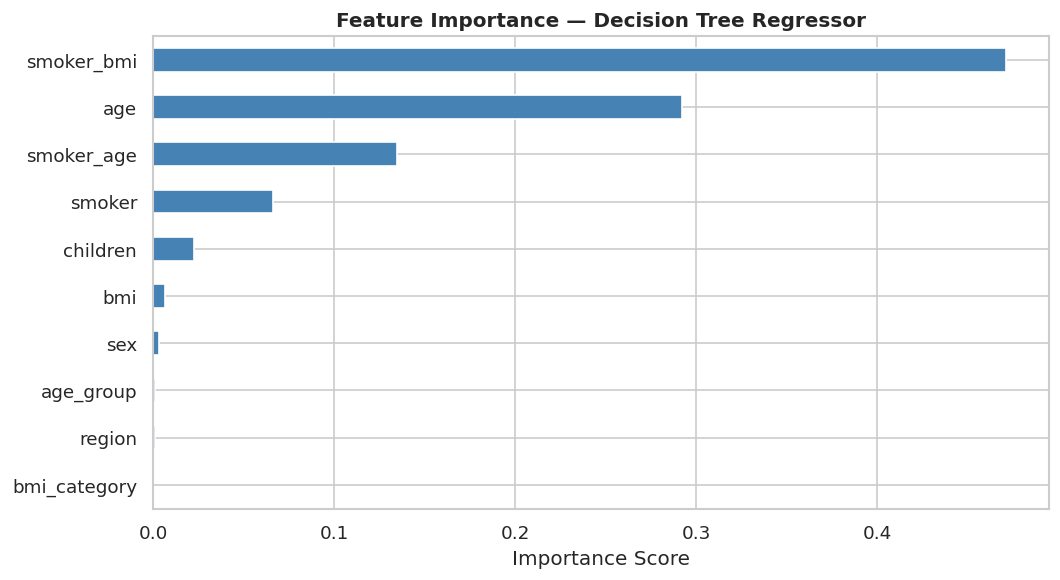

In [ ]:
# Feature Importance — Decision Tree
importances = pd.Series(dt_reg.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Feature Importance — Decision Tree Regressor', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# MODEL 2: Naïve Bayes Regressor
# ============================================================
print('='*55)
print('  MODEL 2: Naïve Bayes Regressor (Custom)')
print('='*55)

nb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', GaussianNBRegressor())
])

nb_params = {
    'reg__n_bins'      : [10, 15, 20, 30, 50],
    'reg__var_smoothing': [1e-9, 1e-7, 1e-5, 1e-3]
}

nb_grid = GridSearchCV(
    estimator=nb_pipeline,
    param_grid=nb_params,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
nb_grid.fit(X, y)

print(f'Best Params  : {nb_grid.best_params_}')
print(f'Best CV RMSE : ${-nb_grid.best_score_:,.2f}')

nb_best = nb_grid.best_estimator_
nb_pred = cross_val_predict(nb_best, X, y, cv=kf)

print('\nMetrik (cross-val predict):')
nb_metrics = regression_metrics(y, nb_pred, label=True)

  MODEL 2: Naïve Bayes Regressor (Custom)
Best Params  : {'reg__n_bins': 30, 'reg__var_smoothing': 0.001}
Best CV RMSE : $4,859.30

Metrik (cross-val predict):
  MAE  : $2,374.87
  RMSE : $4,870.46
  R²   : 0.8381
  MAPE : 16.49%


In [ ]:
# ============================================================
# MODEL 3: KNN Regressor
# ============================================================
print('='*55)
print('  MODEL 3: K-Nearest Neighbors Regressor')
print('='*55)

knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', KNeighborsRegressor())
])

knn_params = {
    'reg__n_neighbors': [3, 5, 7, 9, 11, 15, 20],
    'reg__weights'    : ['uniform', 'distance'],
    'reg__metric'     : ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_params,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
knn_grid.fit(X, y)

print(f'Best Params  : {knn_grid.best_params_}')
print(f'Best CV RMSE : ${-knn_grid.best_score_:,.2f}')

knn_best = knn_grid.best_estimator_
knn_pred = cross_val_predict(knn_best, X, y, cv=kf)

print('\nMetrik (cross-val predict):')
knn_metrics = regression_metrics(y, knn_pred, label=True)

  MODEL 3: K-Nearest Neighbors Regressor
Best Params  : {'reg__metric': 'manhattan', 'reg__n_neighbors': 20, 'reg__weights': 'uniform'}
Best CV RMSE : $4,780.03

Metrik (cross-val predict):
  MAE  : $2,787.29
  RMSE : $4,786.61
  R²   : 0.8437
  MAPE : 31.93%


---
## 3.6 Hasil & Analisis

In [ ]:
# ============================================================
# 3.6.1 — Tabel Perbandingan Metrik
# ============================================================
model_names = ['Decision Tree', 'Naïve Bayes', 'KNN']
all_metrics = [dt_metrics, nb_metrics, knn_metrics]
preds_all   = [dt_pred, nb_pred, knn_pred]

results_df = pd.DataFrame(all_metrics, index=model_names).round(2)
results_df['MAE']  = results_df['MAE'].apply(lambda x: f'${x:,.2f}')
results_df['RMSE'] = results_df['RMSE'].apply(lambda x: f'${x:,.2f}')
results_df['MAPE'] = results_df['MAPE'].apply(lambda x: f'{x:.2f}%')

print('Perbandingan Performa Model (Cross-Validation 5-Fold):')
results_df

Perbandingan Performa Model (Cross-Validation 5-Fold):


,MAE,RMSE,R²,MAPE
Decision Tree,"$1,889.08","$4,692.94",0.85,13.19%
Naïve Bayes,"$2,374.87","$4,870.46",0.84,16.49%
KNN,"$2,787.29","$4,786.61",0.84,31.93%


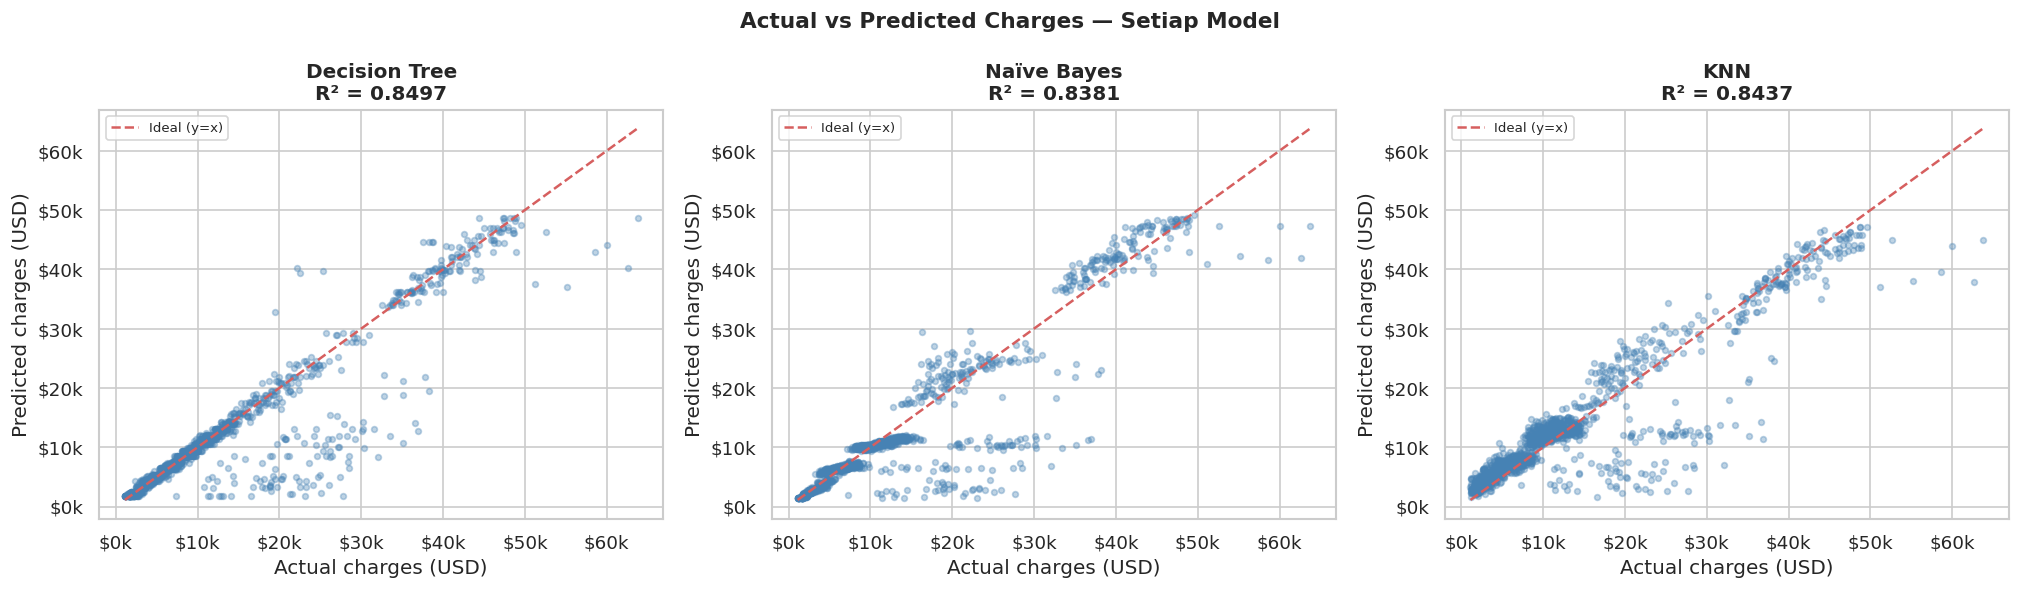

In [ ]:
# ============================================================
# 3.6.2 — Scatter Plot: Actual vs Predicted
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Actual vs Predicted Charges — Setiap Model', fontsize=13, fontweight='bold')

for ax, name, pred in zip(axes, model_names, preds_all):
    r2 = r2_score(y, pred)
    ax.scatter(y, pred, alpha=0.35, s=12, color='steelblue')
    lims = [min(y.min(), pred.min()), max(y.max(), pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Ideal (y=x)')
    ax.set_xlabel('Actual charges (USD)')
    ax.set_ylabel('Predicted charges (USD)')
    ax.set_title(f'{name}\nR² = {r2:.4f}', fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

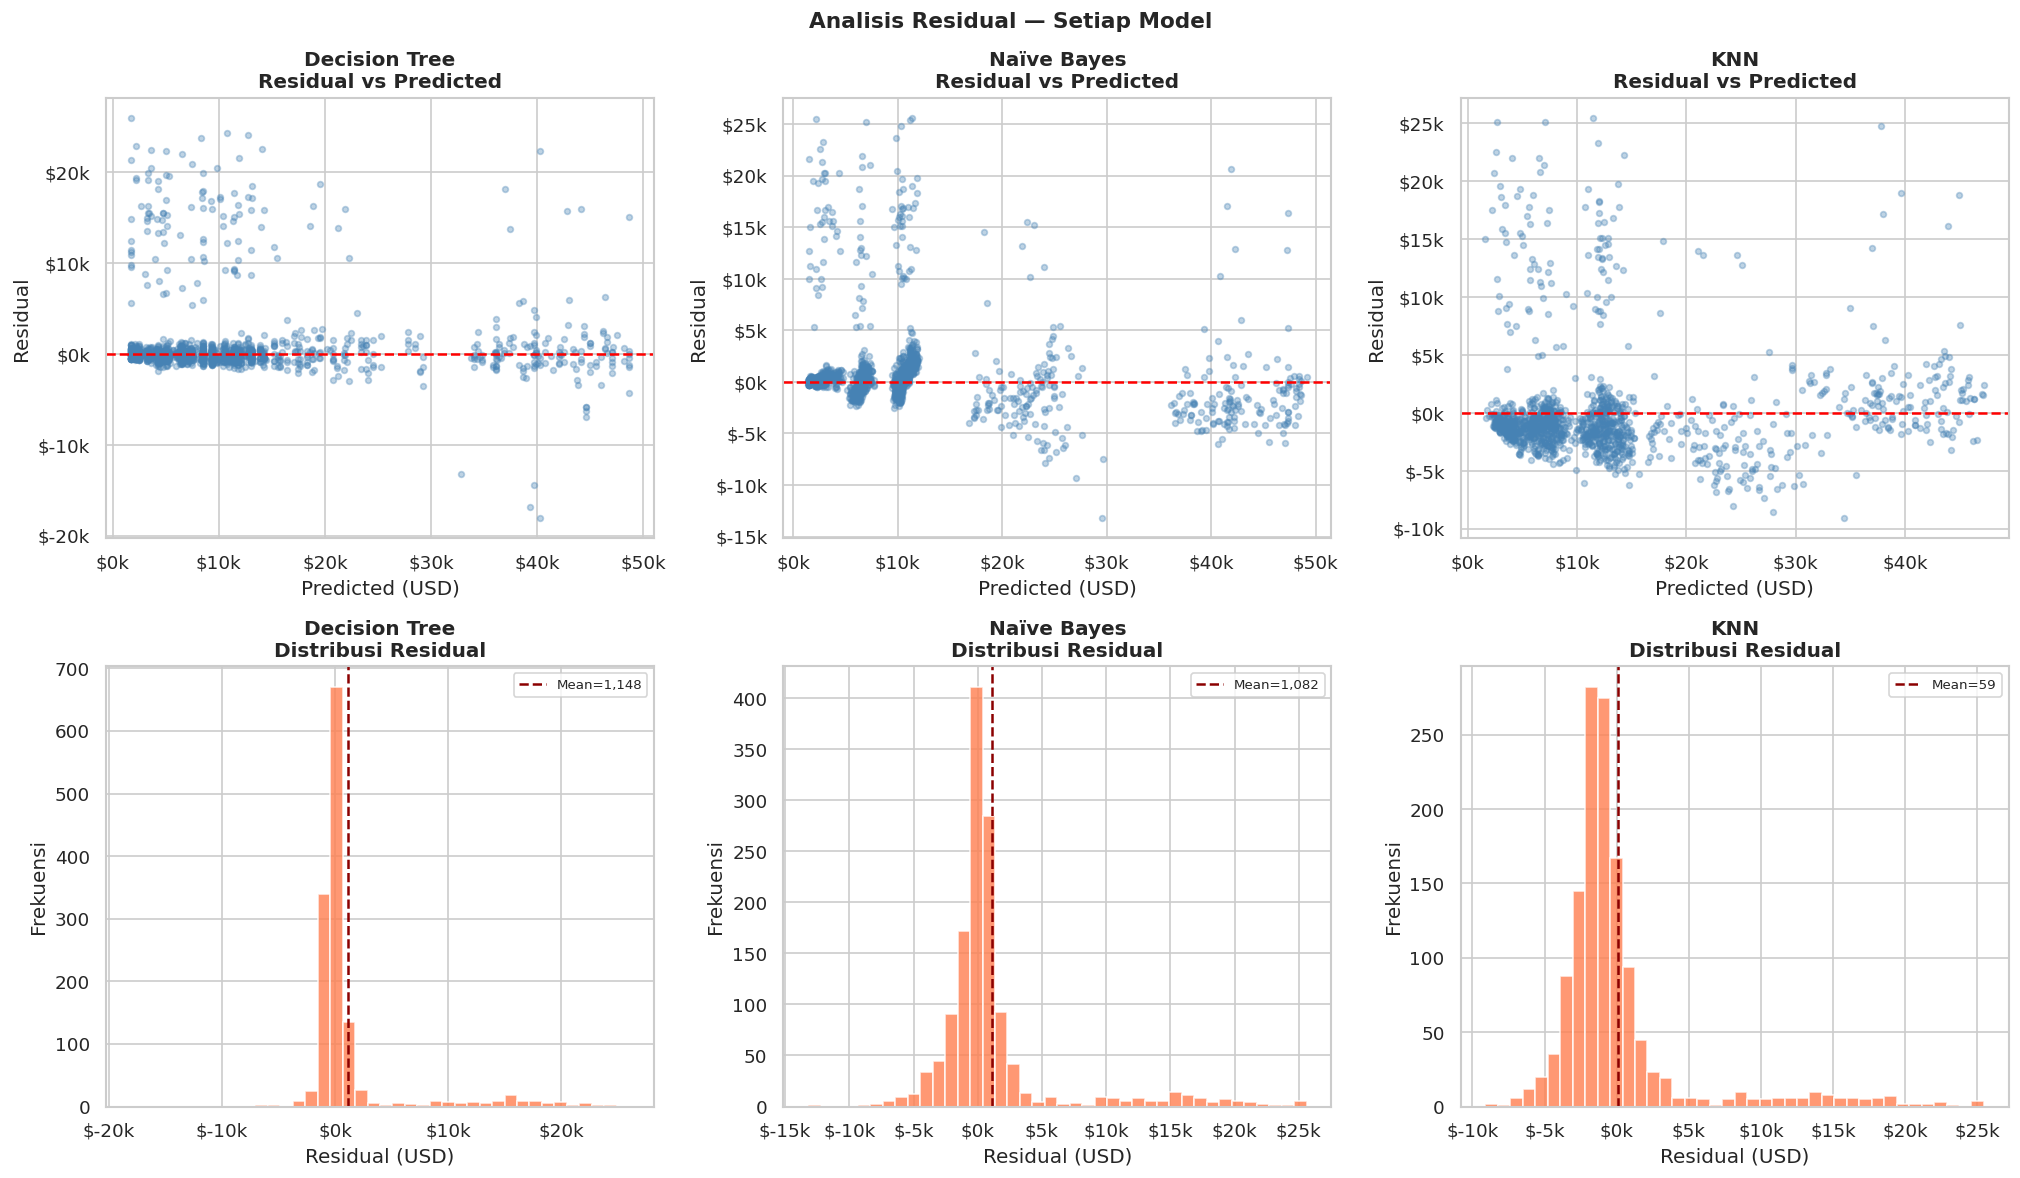

In [ ]:
# ============================================================
# 3.6.3 — Residual Analysis (Error Analysis)
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Analisis Residual — Setiap Model', fontsize=13, fontweight='bold')

for i, (name, pred) in enumerate(zip(model_names, preds_all)):
    residuals = np.array(y) - np.array(pred)

    # Residual vs Predicted
    axes[0, i].scatter(pred, residuals, alpha=0.35, s=12, color='steelblue')
    axes[0, i].axhline(0, color='red', linestyle='--', linewidth=1.5)
    axes[0, i].set_title(f'{name}\nResidual vs Predicted', fontweight='bold')
    axes[0, i].set_xlabel('Predicted (USD)')
    axes[0, i].set_ylabel('Residual')
    axes[0, i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    axes[0, i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

    # Distribusi Residual
    axes[1, i].hist(residuals, bins=40, color='coral', edgecolor='white', alpha=0.8)
    axes[1, i].axvline(residuals.mean(), color='darkred', linestyle='--',
                        linewidth=1.5, label=f'Mean={residuals.mean():,.0f}')
    axes[1, i].set_title(f'{name}\nDistribusi Residual', fontweight='bold')
    axes[1, i].set_xlabel('Residual (USD)')
    axes[1, i].set_ylabel('Frekuensi')
    axes[1, i].legend(fontsize=8)
    axes[1, i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.tight_layout()
plt.show()

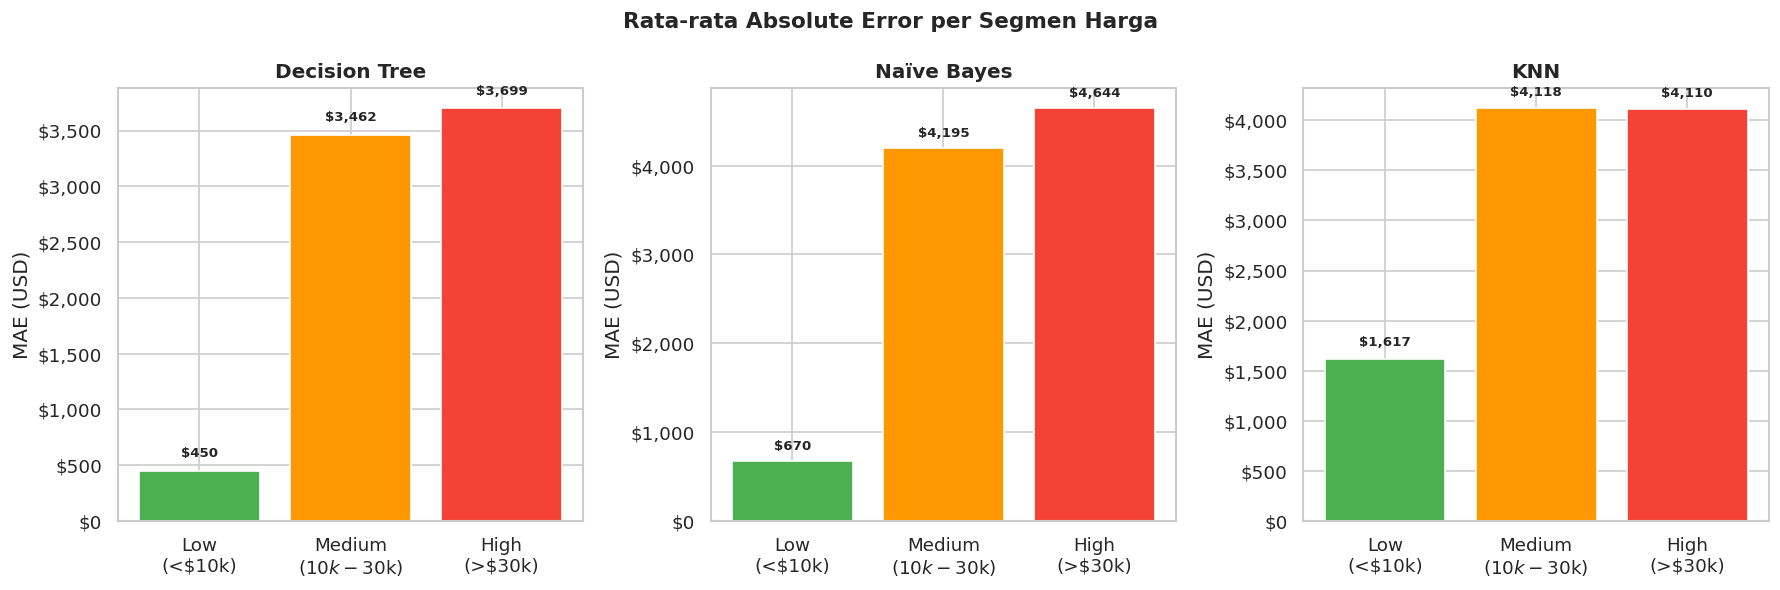


MAE per Segmen Harga:


,Decision Tree,Naïve Bayes,KNN
Low (<$10k),$450.38,$669.88,"$1,617.12"
Medium ($10k-$30k),"$3,461.90","$4,195.13","$4,118.38"
High (>$30k),"$3,698.53","$4,644.29","$4,110.49"


In [ ]:
# ============================================================
# 3.6.4 — Error Segmentation: Error per Range Charges
# (Analog dengan analisis confidence pada klasifikasi)
# ============================================================
bins_labels = ['Low\n(<$10k)', 'Medium\n($10k-$30k)', 'High\n(>$30k)'
]
bins = [0, 10000, 30000, 100000]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Rata-rata Absolute Error per Segmen Harga', fontsize=13, fontweight='bold')

for ax, name, pred in zip(axes, model_names, preds_all):
    y_np      = np.array(y)
    pred_np   = np.array(pred)
    abs_error = np.abs(y_np - pred_np)

    seg_mae = []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_np >= lo) & (y_np < hi)
        seg_mae.append(abs_error[mask].mean() if mask.sum() > 0 else 0)

    colors = ['#4CAF50', '#FF9800', '#F44336']
    bars = ax.bar(bins_labels, seg_mae, color=colors, edgecolor='white')
    for bar, val in zip(bars, seg_mae):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'${val:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('MAE (USD)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

# Tabel Numerik
print('\nMAE per Segmen Harga:')
seg_data = {}
for name, pred in zip(model_names, preds_all):
    y_np    = np.array(y)
    abs_err = np.abs(y_np - np.array(pred))
    row = []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_np >= lo) & (y_np < hi)
        row.append(abs_err[mask].mean() if mask.sum() > 0 else 0)
    seg_data[name] = row

seg_df = pd.DataFrame(seg_data, index=['Low (<$10k)', 'Medium ($10k-$30k)', 'High (>$30k)']).round(2)
seg_df.applymap(lambda x: f'${x:,.2f}')

In [ ]:
# ============================================================
# 3.6.5 — Worst Predictions: Observasi dengan Error Terbesar
# ============================================================
print('=== Analisis Kesalahan Terbesar (Top-10 per Model) ===\n')

for name, pred in zip(model_names, preds_all):
    abs_err    = np.abs(np.array(y) - np.array(pred))
    pct_err    = abs_err / (np.array(y) + 1e-8) * 100
    top10_idx  = np.argsort(abs_err)[-10:][::-1]

    print(f'[{name}] — Top-10 prediksi terburuk (error absolut terbesar):')
    detail = df.iloc[top10_idx][['age', 'bmi', 'smoker', 'charges']].copy()
    detail['predicted']   = pred[top10_idx].round(2)
    detail['abs_error']   = abs_err[top10_idx].round(2)
    detail['pct_error']   = pct_err[top10_idx].round(2)
    detail.columns = ['age', 'bmi', 'smoker', 'actual', 'predicted', 'abs_error', 'pct_error%']
    print(detail.to_string(index=False))
    print(f'  Rata-rata error terbesar: ${abs_err[top10_idx].mean():,.2f}\n')

=== Analisis Kesalahan Terbesar (Top-10 per Model) ===

[Decision Tree] — Top-10 prediksi terburuk (error absolut terbesar):
 age    bmi smoker      actual  predicted  abs_error  pct_error%
  20 35.310     no 27724.28875    1719.90   26004.39       93.80
  55 26.800     no 35160.13457   10796.35   24363.78       69.29
  59 34.800     no 36910.60803   12784.63   24125.98       65.36
  44 29.735     no 32108.66282    8360.44   23748.22       73.96
  24 23.210     no 25081.76784    2211.13   22870.64       91.18
  61 33.330     no 36580.28216   14063.42   22516.86       61.55
  21 32.680     no 26018.95052    3591.48   22427.47       86.20
  45 30.360    yes 62592.87309   40224.08   22368.79       35.74
  34 22.420     no 27375.90478    5068.84   22307.06       81.48
  40 41.420     no 28476.73499    6498.56   21978.17       77.18
  Rata-rata error terbesar: $23,271.14

[Naïve Bayes] — Top-10 prediksi terburuk (error absolut terbesar):
 age    bmi smoker      actual  predicted  abs_error 

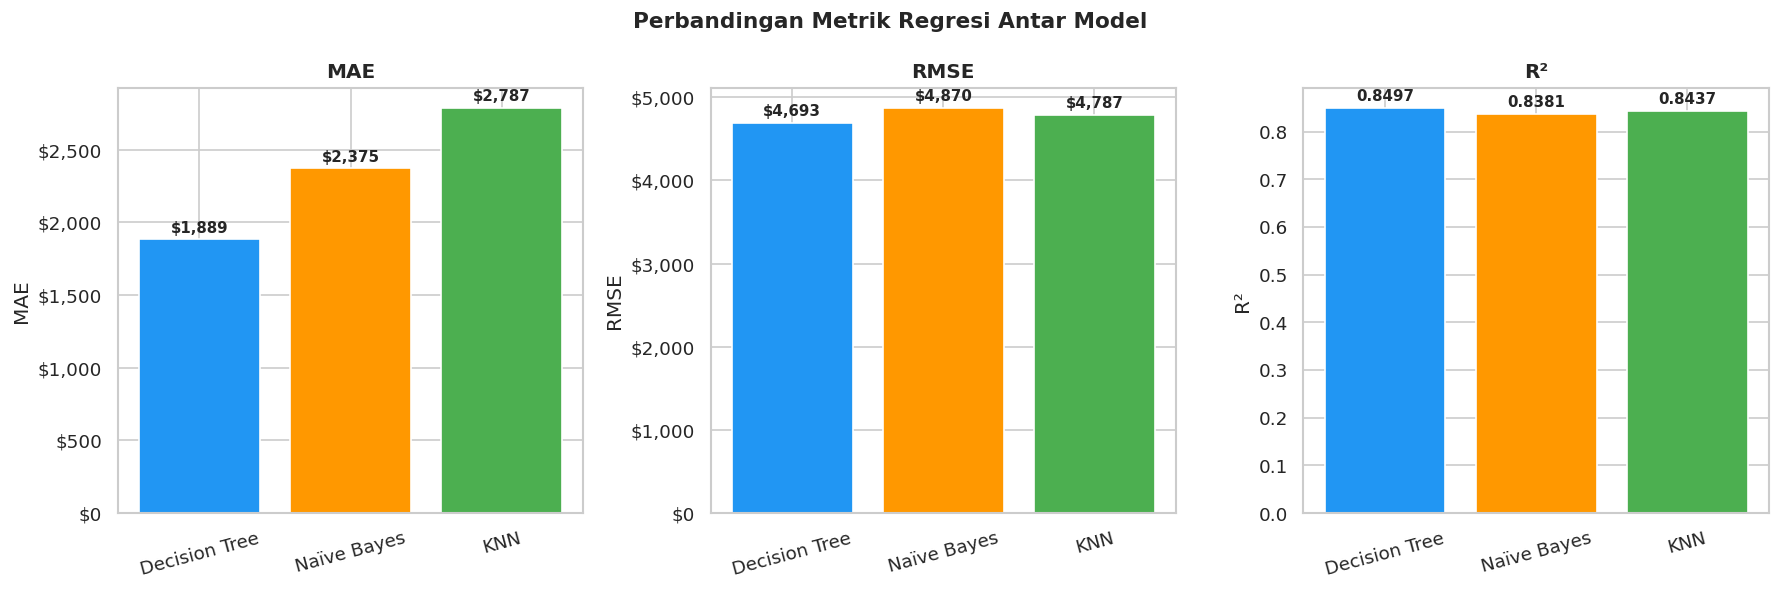

In [ ]:
# ============================================================
# 3.6.6 — Bar Chart Ringkasan Metrik Numerik
# ============================================================
metrics_num = {
    name: regression_metrics(y, pred)
    for name, pred in zip(model_names, preds_all)
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Perbandingan Metrik Regresi Antar Model', fontsize=13, fontweight='bold')

colors = ['#2196F3', '#FF9800', '#4CAF50']

for metric, ax in zip(['MAE', 'RMSE', 'R²'], axes):
    vals = [metrics_num[n][metric] for n in model_names]
    bars = ax.bar(model_names, vals, color=colors, edgecolor='white')
    for bar, val in zip(bars, vals):
        label = f'{val:.4f}' if metric == 'R²' else f'${val:,.0f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                label, ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    if metric in ['MAE', 'RMSE']:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

---
## 3.7 Kesimpulan

In [ ]:
# ============================================================
# RINGKASAN AKHIR
# ============================================================
metrics_num_df = pd.DataFrame(metrics_num).T.round(2)
metrics_num_df['MAE']  = metrics_num_df['MAE'].apply(lambda x: f'${x:,.2f}')
metrics_num_df['RMSE'] = metrics_num_df['RMSE'].apply(lambda x: f'${x:,.2f}')
metrics_num_df['MAPE'] = metrics_num_df['MAPE'].apply(lambda x: f'{x:.2f}%')

print('=' * 65)
print('  RINGKASAN HASIL EKSPERIMEN — REGRESI')
print('=' * 65)
print(metrics_num_df.to_string())

# Pemenang
r2_vals  = {n: metrics_num[n]['R²'] for n in model_names}
mae_vals = {n: metrics_num[n]['MAE'] for n in model_names}
best_r2  = max(r2_vals, key=r2_vals.get)
best_mae = min(mae_vals, key=mae_vals.get)

print(f'\n🏆 Model dengan R² tertinggi  : {best_r2} ({r2_vals[best_r2]:.4f})')
print(f'🏆 Model dengan MAE terendah  : {best_mae} (${mae_vals[best_mae]:,.2f})')

print('\nCatatan Interpretasi:')
print('  - Decision Tree : tangkap non-linearitas, cenderung overfit tanpa pruning')
print('  - Naïve Bayes   : ringan & cepat, akurasi regresi terbatas (asumsi kuat)')
print('  - KNN           : performa solid, tapi lambat saat prediksi data besar')
print('  - Fitur smoker + interaksi smoker_bmi / smoker_age sangat dominan')
print('  - Segmen "High" charges cenderung lebih sulit diprediksi semua model')

  RINGKASAN HASIL EKSPERIMEN — REGRESI
                     MAE       RMSE    R²    MAPE
Decision Tree  $1,889.08  $4,692.94  0.85  13.19%
Naïve Bayes    $2,374.87  $4,870.46  0.84  16.49%
KNN            $2,787.29  $4,786.61  0.84  31.93%

🏆 Model dengan R² tertinggi  : Decision Tree (0.8497)
🏆 Model dengan MAE terendah  : Decision Tree ($1,889.08)

Catatan Interpretasi:
  - Decision Tree : tangkap non-linearitas, cenderung overfit tanpa pruning
  - Naïve Bayes   : ringan & cepat, akurasi regresi terbatas (asumsi kuat)
  - KNN           : performa solid, tapi lambat saat prediksi data besar
  - Fitur smoker + interaksi smoker_bmi / smoker_age sangat dominan
  - Segmen "High" charges cenderung lebih sulit diprediksi semua model
